# 🌊 BinWaves North Carolina (Propagation)

> **Inputs:**
> - Bathymetry file in `.nc` format, located in the `inputs/` folder.  
>
> **ℹ️ NOTE:** If bathymetry data for the study area is not available, free GEBCO bathymetry (~400 m resolution) can be used:
> - **Download GEBCO bathymetry data:** [https://download.gebco.net/](https://download.gebco.net/)
> - Example notebook for working with GEBCO data:  
>   [Download_GEBCO_Bathymetry_Data.ipynb](https://github.com/GeoOcean/BlueMath/blob/clean/binwaves/toolkit/data/Download_GEBCO_Bathymetry_Data.ipynb)
>
> **Outputs:**
> - SWAN case configuration in `.csv` format.
> - `Kp_coefficients.nc` file saved in the `outputs/` folder.


### BinWaves Notebooks Overview

This Jupyter Notebook is the first of three in the **BinWaves** modeling workflow, following Cagigal et al., 2024 :

1. `BinWaves_Propagation.ipynb`  
2. `BinWaves_Reconstruction.ipynb`  
3. `BinWaves_Validation.ipynb`

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk

- **BlueMath Toolkit Repository**:  [https://github.com/GeoOcean/BlueMath_tk.git](https://github.com/GeoOcean/BlueMath_tk.git)

Before continuing, ensure you have **created and activated a Python environment**.

*** Other Required Packages ***
- `wavespectra` 
- `cartophy`
 
---

<details open>
<summary><strong>📁 BinWaves_Propagation.ipynb</strong></summary>

This notebook constructs the **library of pre-run cases** for all **monochromatic wave systems**.

</details>

---

<details>
<summary><strong>📁 BinWaves_Reconstruction.ipynb</strong></summary>

This notebook reconstructs **wave conditions** using **offshore directional wave spectra**.

##### Requirements:

- Offshore wave spectrum data (e.g., **CAWCR** or **ERA5** datasets).

- **OPTIONAL 1**: Apply **satellite corrections** to the hindcast spectrum before running BinWaves using the `CalVal` tool in the BlueMath toolkit. An example is provided in the Jupyter Notebook **Satellite Correction**.

- **OPTIONAL 2**: A **Super Point Spectrum** can be also used as input to the hindcast spectrum before running BinWaves. The `SuperPoint` aggregates the energy from a number of points (Wave Spectra) surrounding the study site (Cagigal et al., 2021).  An example is provided in the Jupyter Notebook **Super Point Computation** .

</details>

---

<details>
<summary><strong>📁 BinWaves_Validation.ipynb</strong></summary>

This notebook performs **validation** using **wave buoy data**, if available.

##### Requirements:

- Wave buoy data in a format compatible with BinWaves (if available).
- Some wave buoy data can be freely downloaded from:  
  🌊 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

- **NOTE:** You can use the `NDBC_buoy_data.ipynb` notebook to:
  - Download the buoy data.
  - Convert it into the appropriate format for BinWaves.

</details>

### 📌 In This Notebook: `BinWaves_Propagation.ipynb`

This notebook handles the **construction of the wave propagation library** by simulating wave cases.

### Steps:

- Generate wave conditions for all specified **frequencies** and **directions**.
- Set up and run SWAN simulations.
- Extract and save outputs from each simulation.
- Visualize the full wave library, including larger illustrative examples.


> ⚠️ **Coordinate System Note**  
> The BinWaves (SWAN) model can run in either **Spherical** or **Cartesian** coordinates:
> - Use **spherical coordinates** for areas larger than **100 km**.
> - Make sure your bathymetry file matches the coordinate system used in your simulation.

## Generate computational bathymetry

> ⚠️ **NOTE**  
> 
> - Functions expect coordinate columns to follow standard naming conventions.
> - For geographic coordinates, use: 'lon', 'lat', 'longitude', or 'latitude'.
> - For UTM coordinates, use: 'x', 'y', 'X', 'Y', 'cx', 'cy', 'easting', or 'northing'.
> - Ensure your data uses one of these names—otherwise, rename the coordinates accordingly
> - The bathymetry should have positive values for sea and negative values for land.



In [1]:
import xarray as xr
import numpy as np

In [2]:
from utils.plotting import detect_coordinate_system

ds = xr.open_dataset("inputs/gebco_bathymetry.nc")
coords = detect_coordinate_system(ds)
is_geographic = coords["is_geographic"]
x_coord = coords["x_coord"]
y_coord = coords["y_coord"]


bathy = -(ds.transpose(y_coord, x_coord).sortby(y_coord, ascending=False).elevation)
bathy

<xarray.DataArray 'elevation' (lat: 1342, lon: 1533)> Size: 4MB
array([[-297, -278, -270, ..., 2808, 2810, 2813],
       [-273, -282, -270, ..., 2811, 2812, 2812],
       [-272, -256, -254, ..., 2814, 2815, 2813],
       ...,
       [  64,   65,   65, ..., 5320, 5322, 5322],
       [  65,   66,   65, ..., 5322, 5322, 5322],
       [  66,   66,   66, ..., 5325, 5324, 5322]],
      shape=(1342, 1533), dtype=int16)
Coordinates:
  * lat      (lat) float64 11kB 37.57 37.57 37.56 37.56 ... 31.99 31.99 31.99
  * lon      (lon) float64 12kB -79.39 -79.39 -79.39 ... -73.02 -73.01 -73.01
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    grid_mapping:        crs
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres

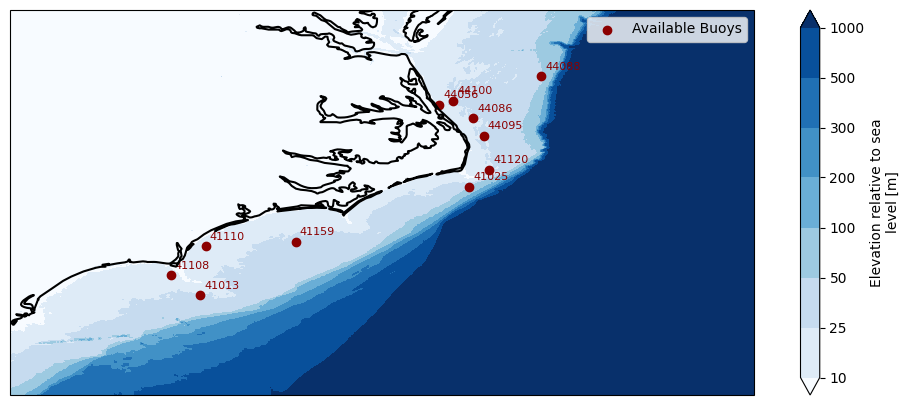

In [3]:
from utils.plotting import plot_selected_bathy

# if NOT buoys or other locations of interest just run plot_selected_bathy(bathy=bathy)
buoys_geo = {
    "44088": (-74.8390, 36.6120),
    "44100": (-75.5930, 36.2580),
    "44086": (-75.4210, 36.0010),
    "44056": (-75.7140, 36.2000),
    "44095": (-75.3300, 35.7500),
    "41120": (-75.2850, 35.2580),
    "41025": (-75.4540, 35.0100),
    "41159": (-76.9440, 34.2110),
    "41110": (-77.7150, 34.1420),
    "41013": (-77.7640, 33.4410),
    "41108": (-78.0160, 33.7210),
}
plot_selected_bathy(bathy=bathy, buoys=buoys_geo)

## SWAN Grid Parameters

This section defines the computational grid for running the SWAN model:

- **`xpc`, `ypc`**: Origin coordinates of the grid (in meters for Cartesian, degrees for spherical).  
  - Default = `0.0` for Cartesian; required for spherical.

- **`alpc`**: Angle of the positive x-axis (degrees, Cartesian convention).  
  - Default = `0.0`.

- **`xlenc`, `ylenc`**: Grid length in the x- and y-directions.  
  - Units: meters (Cartesian), degrees (spherical).  

- **`mxc`, `myc`**: Number of grid cells in x- and y-directions (1 less than number of grid points).  
  - In 1D mode, `myc` = `0`.

<center>
    <img src="./assets/SWAN_grid.png" width="80%">
</center>

In [4]:
from utils.operations import calculate_initial_grid_parameters

#NOTE: If you want the grid to pass trough specific points. If you already now grid rotation, origin and length, you can skip this step.
lonA, latA = -77.7640, 33.4410  # origin
lonB, latB = -75.4000, 35.0100  # along x
lonC, latC = -74.8400, 36.6100  # far corner

xpc, ypc, alpc, xlenc, ylenc =calculate_initial_grid_parameters(lonA, latA, lonB, latB, lonC, latC, padding_degrees=0.005)
ylenc = ylenc + 0.3
print(f"xpc: {xpc:.2f}, ypc: {ypc:.2f}, "
      f"alpc: {alpc:.2f}, xlenc: {xlenc:.2f}, "
      f"ylenc: {ylenc:.2f}")

xpc: -77.77, ypc: 33.44, alpc: 33.57, xlenc: 4.20, ylenc: 1.33


In [5]:
# COMPUTATIONAL GRID PARAMETERS
from bluemath_tk.topo_bathy.swan_grid import generate_grid_parameters

grid_parameters, cropped_bathy, corners = generate_grid_parameters(
   bathy, alpc, xpc, ypc, xlenc, ylenc, buffer_distance=0.1
)
cropped_bathy.to_netcdf("outputs/cropped_bathy_North_Carolina.nc")
grid_parameters

Cropping bounds: x=[-78.6083026995451, -74.17265442364264], y=[33.339599018951816, 36.97241696712684]


{'xpc': np.float64(-77.7709308911478),
 'ypc': np.float64(33.43959901895182),
 'alpc': np.float64(33.57245172151295),
 'xlenc': np.float64(4.198667940673296),
 'ylenc': np.float64(1.3334245857783886),
 'mxc': 1007,
 'myc': 319,
 'xpinp': np.float64(-78.60625),
 'ypinp': np.float64(33.34375),
 'alpinp': 0,
 'mxinp': 1064,
 'myinp': 870,
 'dxinp': np.float64(0.004166666666662877),
 'dyinp': np.float64(0.004166666666677088)}

## Desired locations for Model outputs


> ⚠️ **NOTE**  
> 
> - Output location spacing (out_dx, out_dy) can be specified. If not provided, the output locations will use the same spacing as the SWAN grid. However, for large domains or very fine SWAN grids, it is recommended to decrease the output spacing to reduce computational cost, at least at tasting stages.

In [6]:
# OUTPUT GRID LOCATIONS (KPS)
from utils.operations import locations_grid_outputs
locations = locations_grid_outputs(grid_parameters, out_dx=0.135, out_dy=0.1)
# Combine grid locations with buoy locations
buoy_coords = np.array(list(buoys_geo.values()))   
locations = np.vstack((locations, buoy_coords))
locations

array([[-77.77093089,  33.43959902],
       [-77.66160975,  33.51215607],
       [-77.55228861,  33.58471312],
       ...,
       [-77.715     ,  34.142     ],
       [-77.764     ,  33.441     ],
       [-78.016     ,  33.721     ]], shape=(506, 2))

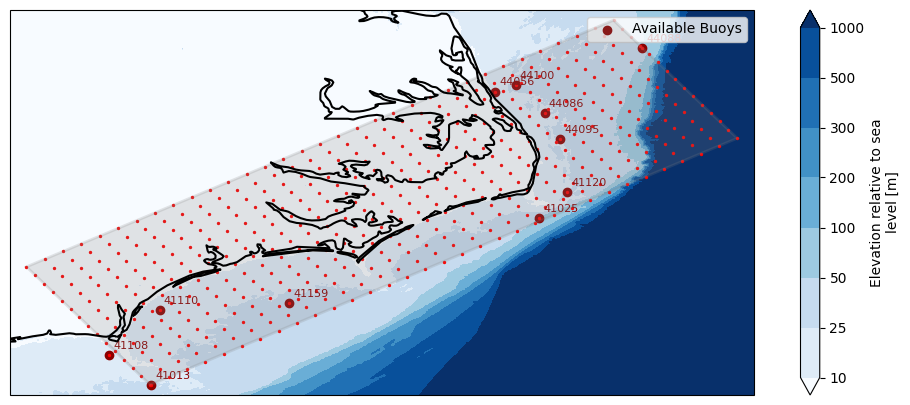

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer
from utils.plotting import plot_selected_bathy, detect_coordinate_system

# Get the projection from your bathy
coords = detect_coordinate_system(bathy)
proj = coords["proj"]
transform = coords["transform"]

# Create the plot with bathymetry and buoys
fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={"projection": proj})
plot_selected_bathy(bathy=cropped_bathy, buoys=buoys_geo, ax=ax)
from matplotlib.patches import Polygon
polygon = Polygon(corners, facecolor='gray', alpha=0.2, edgecolor='gray', 
                 linewidth=2, zorder=15, transform=coords["transform"], label="Computational Grid")
ax.add_patch(polygon)

ax.scatter(
    locations[:, 0],
    locations[:, 1],
    color="red",
    s=2,
    label="Output Locations",
    transform=coords["transform"],
)


## Build and Run SWAN Cases

> 🧘 **NOTE:** If directions and frequencies are used as default, You’re all set! The Bluemath Toolkit takes care of building and running the SWAN cases for you.

In [8]:
import xarray as xr
offshore_spectra=xr.open_dataset("inputs/4466_spec_satellite_corrected.nc")
freq = np.sort(offshore_spectra.spec.freq.values)
dir = np.sort(offshore_spectra.spec.dir.values)
print('freq',freq)
print('dir',dir)

freq [0.035      0.0385     0.04235    0.046585   0.0512435  0.05636785
 0.06200463 0.0682051  0.07502561 0.08252817 0.090781   0.0998591
 0.10984501 0.12082952 0.13291247 0.14620373 0.1608241  0.17690653
 0.19459718 0.21405691 0.2354626  0.25900885 0.28490975 0.31340075
 0.3447408  0.37921488 0.4171364  0.45885003 0.50473505]
dir [  7.5  22.5  37.5  52.5  67.5  82.5  97.5 112.5 127.5 142.5 157.5 172.5
 187.5 202.5 217.5 232.5 247.5 262.5 277.5 292.5 307.5 322.5 337.5 352.5]


In [9]:
from bluemath_tk.waves.binwaves import generate_swan_cases
# Generate swan model parameters
swan_cases_df = (
    generate_swan_cases(
        # Different directions and frequencies can be specified. If not provided the model will use the default values.
        directions_array=dir, 
        frequencies_array=freq,
    )
    .astype(float)
    .to_dataframe()
    .reset_index()
)
swan_cases_df.head()

,dir,freq,hs,tp,spr,gamma
0,7.5,0.035000,1.0,28.571400,2.0,50.0
1,7.5,0.038500,1.0,25.974001,2.0,50.0
2,7.5,0.042350,1.0,23.612801,2.0,50.0
3,7.5,0.046585,1.0,21.466101,2.0,50.0
4,7.5,0.051244,1.0,19.514700,2.0,50.0


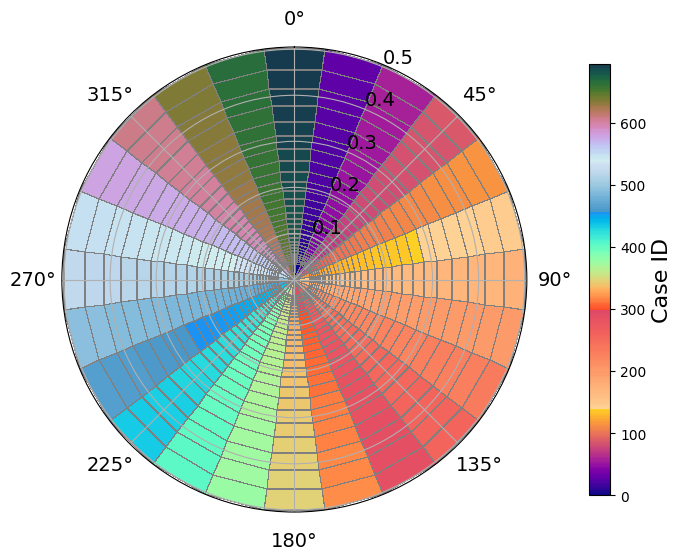

In [10]:
import numpy as np
from bluemath_tk.waves.binwaves import plot_selected_cases_grid
# Plot the cases grid. Specific directions sectors can be specified. 
plot_selected_cases_grid(
    frequencies=freq,
    directions=dir,
    figsize=(8, 8),
)

In [11]:
import os
from bluemath_tk.wrappers.swan.swan_wrapper import generate_fixed_parameters
fixed_parameters = generate_fixed_parameters(grid_parameters, freq, dir)
fixed_parameters

Distribución direccional: CIRCLE


{'xpc': np.float64(-77.7709308911478),
 'ypc': np.float64(33.43959901895182),
 'alpc': np.float64(33.57245172151295),
 'xlenc': np.float64(4.198667940673296),
 'ylenc': np.float64(1.3334245857783886),
 'mxc': 1007,
 'myc': 319,
 'xpinp': np.float64(-78.60625),
 'ypinp': np.float64(33.34375),
 'alpinp': 0,
 'mxinp': 1064,
 'myinp': 870,
 'dxinp': np.float64(0.004166666666662877),
 'dyinp': np.float64(0.004166666666677088),
 'dir_dist': 'CIRCLE',
 'dir1': None,
 'dir2': None,
 'freq_discretization': 29,
 'dir_discretization': 24,
 'mdc': 24,
 'flow': 0.03500000014901161,
 'fhigh': 0.5047350525856018}

In [12]:
import os
from bluemath_tk.wrappers.swan.swan_wrapper import BinWavesWrapper

# # This section generates all necessary SWAN input files, organizing them into separate folders for each case.
# Define the input templates and output directory for the wrapper
templates_dir = os.path.join(os.getcwd(), "templates")
templates_name = ["INPUT"]
output_dir = os.path.join(os.getcwd(), "CASES")

swan_wrapper = BinWavesWrapper(
    templates_dir=templates_dir,
    templates_name=templates_name,
    metamodel_parameters=swan_cases_df.to_dict(orient="list"),
    fixed_parameters=fixed_parameters,
    output_dir=output_dir,
    depth_array=cropped_bathy.values,
    locations=locations.T,
)

2025-08-05 10:05:58,360 - BinWavesWrapper - WARNING - Parameter dir is not in the default_parameters
2025-08-05 10:05:58,360 - BinWavesWrapper - WARNING - Parameter freq is not in the default_parameters
2025-08-05 10:05:58,360 - BinWavesWrapper - WARNING - Parameter hs is not in the default_parameters
2025-08-05 10:05:58,361 - BinWavesWrapper - WARNING - Parameter tp is not in the default_parameters
2025-08-05 10:05:58,361 - BinWavesWrapper - WARNING - Parameter spr is not in the default_parameters
2025-08-05 10:05:58,361 - BinWavesWrapper - WARNING - Parameter gamma is not in the default_parameters


In [ ]:
# Build the input files
swan_wrapper.build_cases(mode="one_by_one")
swan_cases_df.to_csv(os.path.join(output_dir, "swan_cases.csv"), index=False)

## Execute SWAN

> ⏰ **Note:** To monitor the progress of your runs, you can execute the following cell anytime to check how many SWAN cases have completed (100% simulation finished).  
> It may take a while for the first cases to finish, so feel free to run the cell multiple times to stay updated.  
> Once all cases have reached 100%, you can proceed with the rest of the code.  
> You can also run the next cells even if only a few cases have completed, to check that everything is working as expected.



In [ ]:
# Run the model

# swan_wrapper.run_cases_in_background(
#     launcher="/software/geocean/swan/swan_serial.exe", num_workers=15
# )
# swan_wrapper.run_cases_bulk(
#     launcher="sbatch --array=85 sbatch_example.sh"
# )
swan_wrapper.run_cases_bulk(
    launcher="sbatch --array=0-697%50 sbatch_example.sh"
)

In [20]:
swan_wrapper.load_cases()
swan_wrapper.monitor_cases()

,Case,Status
0,0000,100 %
1,0001,100 %
2,0002,100 %
3,0003,100 %
4,0004,100 %
...,...,...
691,0691,100 %
692,0692,100 %
693,0693,100 %
694,0694,99.50 %


In [23]:
# Post-process the output files
import os
cases_bulk_parameters = swan_wrapper.postprocess_cases()
cases_bulk_parameters

<xarray.Dataset> Size: 3GB
Dimensions:   (case_num: 696, Yp: 320, Xp: 1008)
Coordinates:
  * Xp        (Xp) float32 4kB -77.77 -77.77 -77.76 ... -74.28 -74.28 -74.27
  * Yp        (Yp) float32 1kB 33.44 33.44 33.45 33.45 ... 34.54 34.55 34.55
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
Data variables:
    Hsig      (case_num, Yp, Xp) float32 898MB 0.0004678 0.0004719 ... 0.1315
    Tm02      (case_num, Yp, Xp) float32 898MB 28.57 28.57 28.57 ... 1.202 1.202
    Dir       (case_num, Yp, Xp) float32 898MB 41.32 41.32 41.41 ... 359.9 359.9

/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/core/operations.py:349: RuntimeWarning: invalid value encountered in multiply
  x_rad = x_deg * np.pi / 180
/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


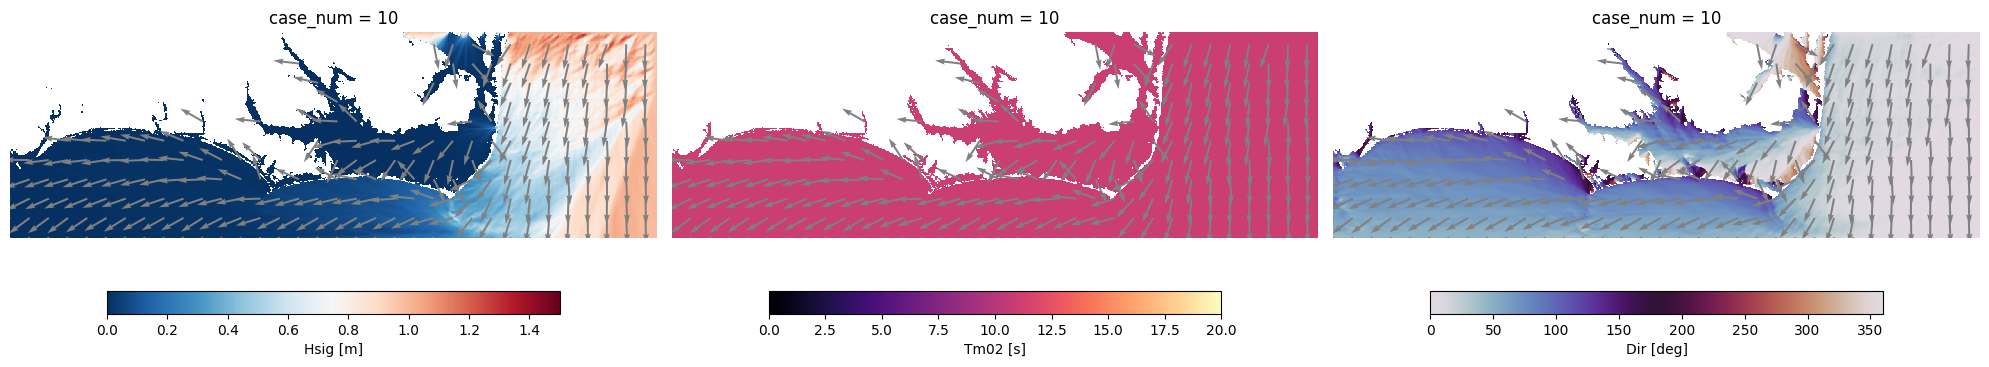

In [24]:
# from utils.plotting import plot_selected_bathy
import importlib
import utils.plotting as plotting
importlib.reload(plotting)
from utils.plotting import plot_case_variables

plot_case_variables(
    data=cases_bulk_parameters.isel(case_num=10),
    step=30,
)

## Plot ALL pre-run cases

/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


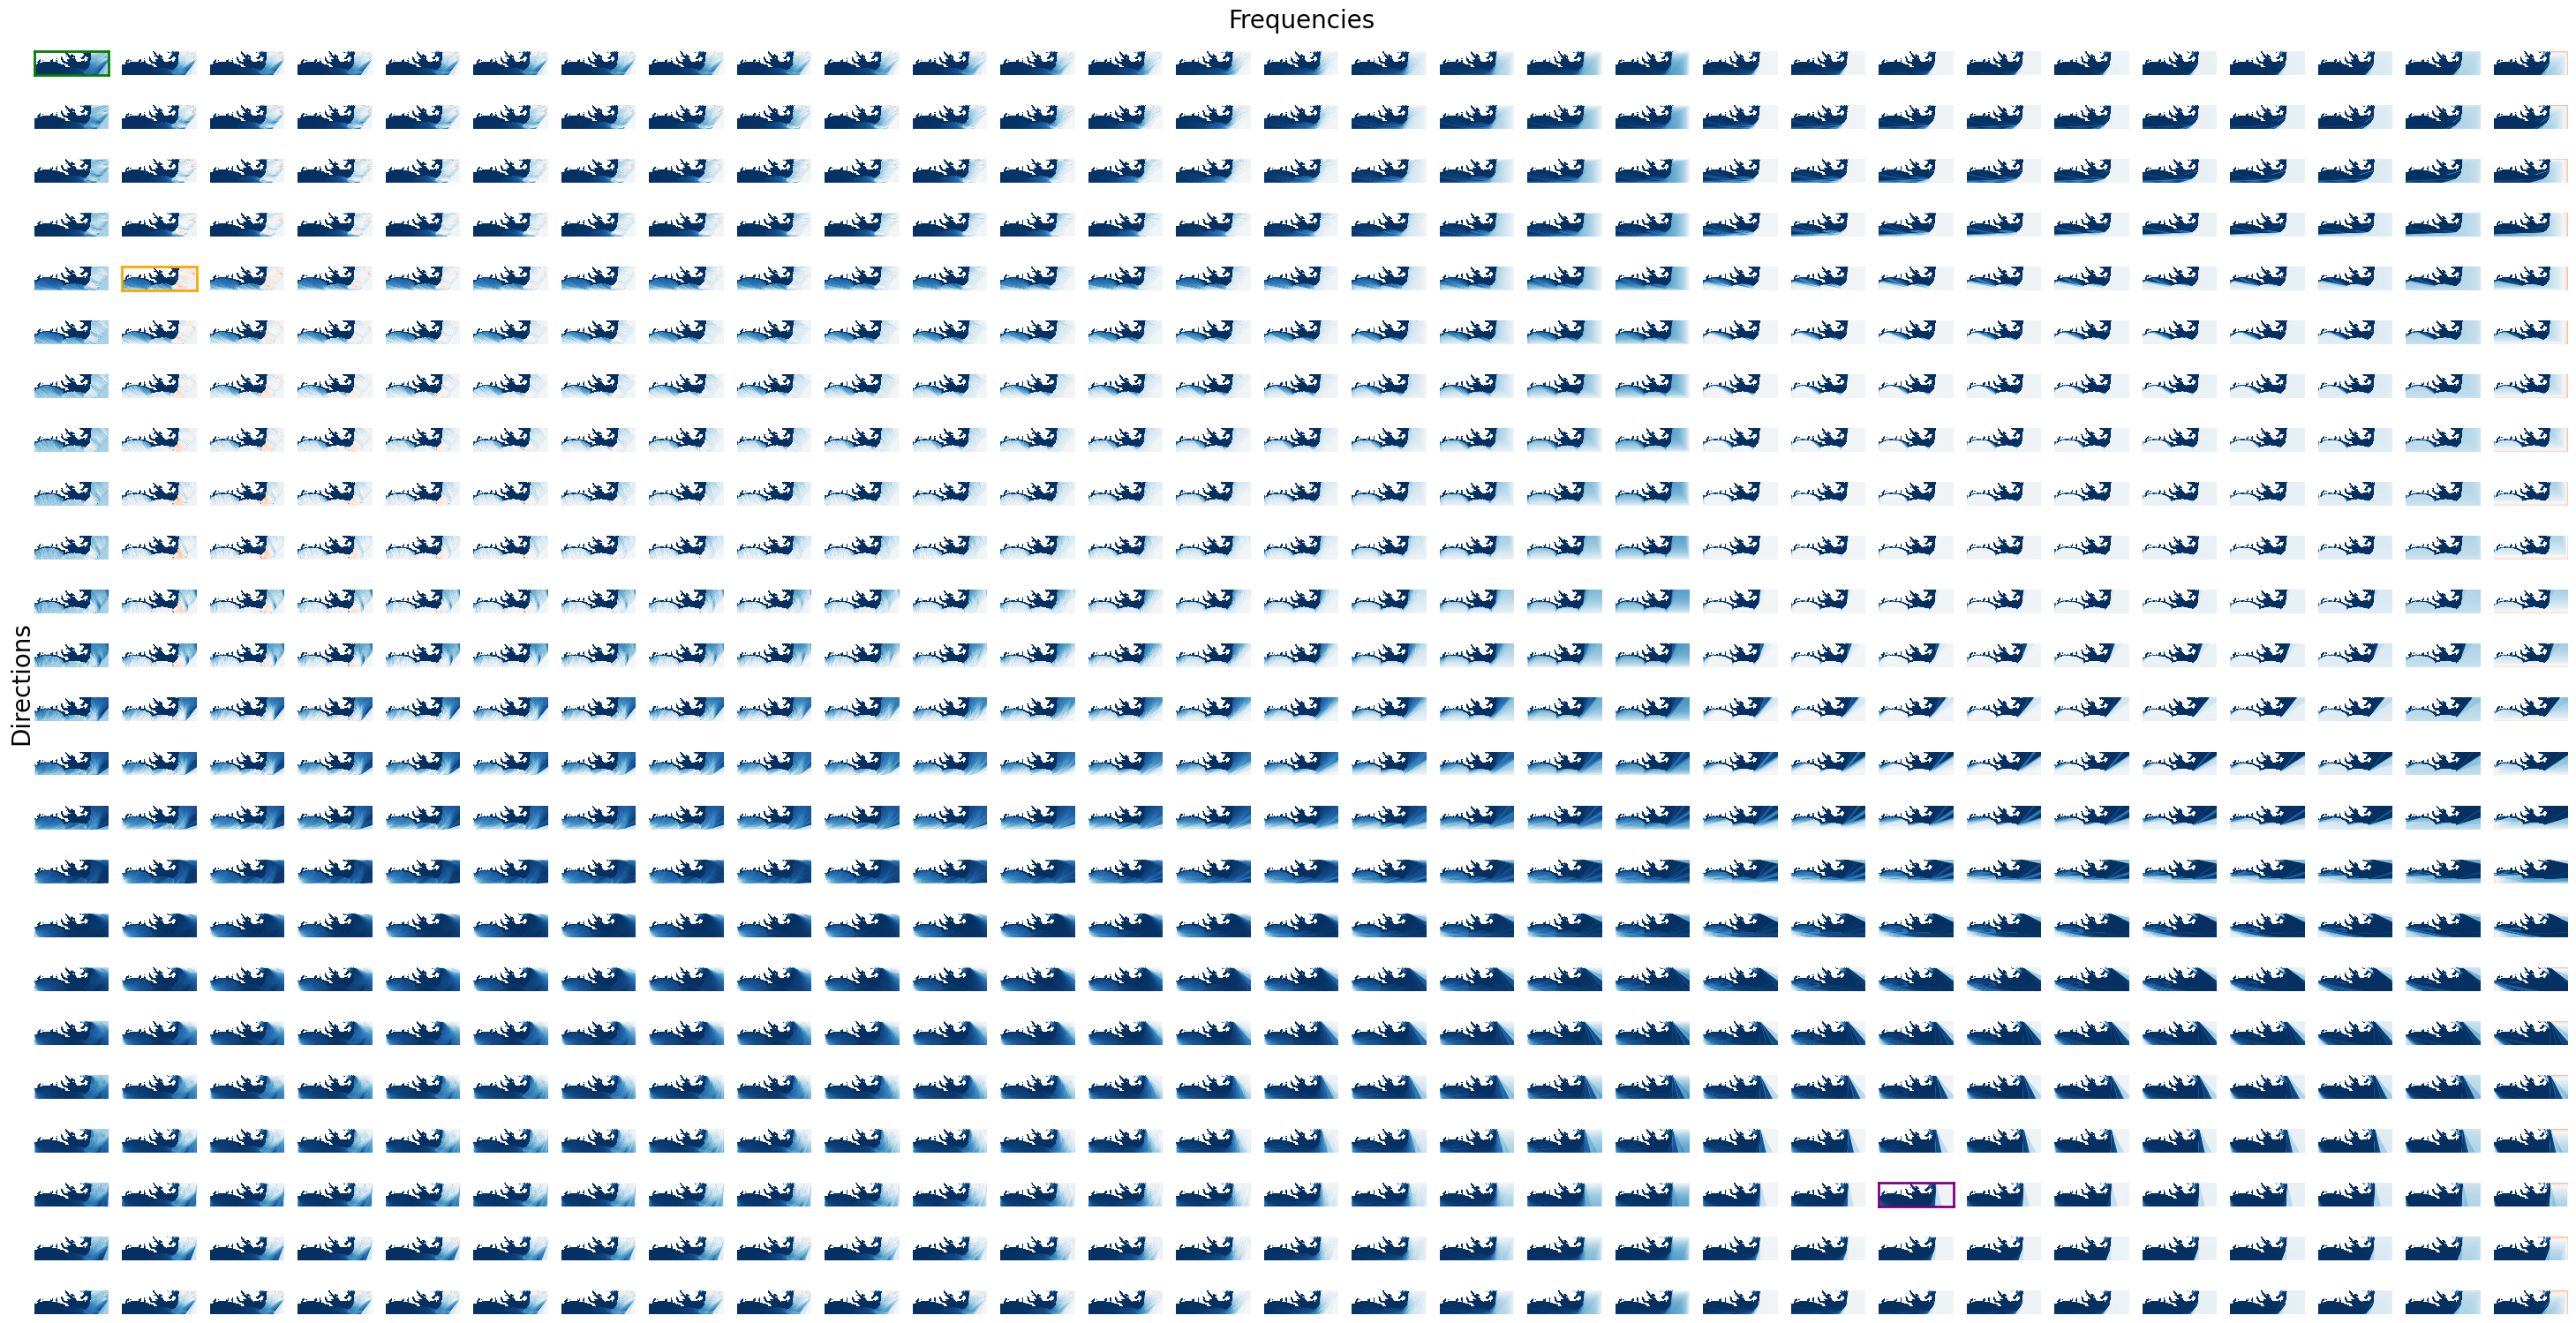

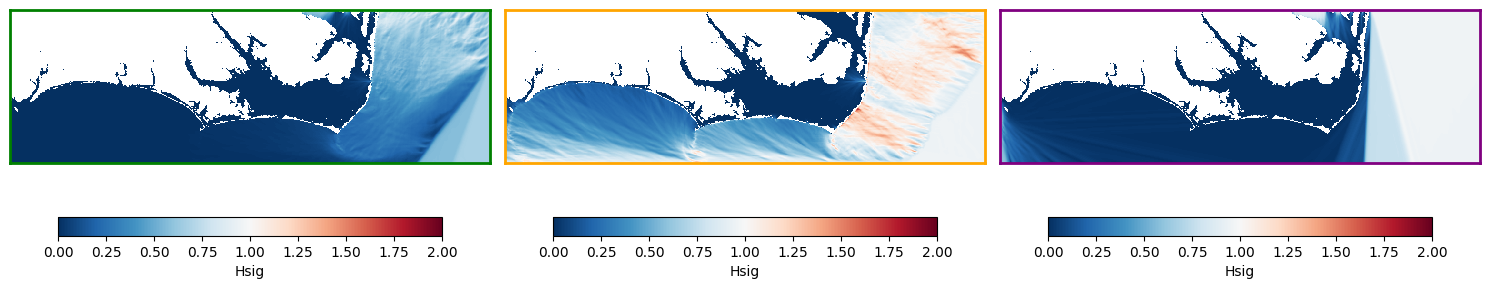

In [25]:
from utils.plotting import plot_cases_grid

plot_cases_grid(
    data=cases_bulk_parameters.Hsig.where(
        cases_bulk_parameters.case_num.isin(
            swan_cases_df.where(swan_cases_df["hs"] == 1.0).dropna().index.values
        ),
        cases_bulk_parameters.Hsig * 10,
    ),
    cases_to_plot=[0, 117, 630],
    num_directions=len(swan_cases_df["dir"].unique()),
    num_frequencies=len(swan_cases_df["freq"].unique()),
)

## Extract kp coefficients

In [26]:
from bluemath_tk.waves.binwaves import process_kp_coefficients

list_of_input_spectra = [
    os.path.join(case_dir, "input_spectra_N.bnd")
    for case_dir in swan_wrapper.cases_dirs
]
list_of_output_spectra = [
    os.path.join(case_dir, "output.spec") for case_dir in swan_wrapper.cases_dirs
]

kp_coefficients = process_kp_coefficients(
    list_of_input_spectra=list_of_input_spectra,
    list_of_output_spectra=list_of_output_spectra,
)
kp_coefficients

<xarray.DataArray 'efth' (case_num: 696, site: 506, freq: 29, dir: 24)> Size: 2GB
array([[[[6.04303975e-10, 1.51982450e-08, 1.78632255e-07, ...,
          0.00000000e+00, 9.54800280e-09, 2.11506391e-09],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[1.88154786e-08, 1.10320972e-07, 1.40845363e-07, ...,
          1.35363156e-10, 3.38407889e-10, 8.93396827e-09],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]]],
      shape=(696, 506, 29, 24))
Coordinates:
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
  * site      (site) int64 4kB 1 2 3 4 5 6 7 8 ... 500 501 502 503 504 505 506
  * freq      (freq) float64 232B 0.035 0.0385 0.0423 ... 0.4171 0.4589 0.5047
  * dir       (dir) float64 192B 3.928 18.93 33.93 48.93 ... 318.9 333.9 348.9
    time      datetime64[ns] 8B 2025-08-05T10:33:00
    lat       float64 8B 0.0
    lon       float64 8B 0.0

In [27]:
kp_coefficients.to_dataset(name="kps").drop(["time"]).assign_coords(
    coord_x=(("site"), swan_wrapper.locations[:, 0]),
    coord_y=(("site"), swan_wrapper.locations[:, 1]),
).to_netcdf("outputs/kp_coefficients.nc")

/tmp/ipykernel_3289679/1460904726.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  kp_coefficients.to_dataset(name="kps").drop(["time"]).assign_coords(
